# Running FAIR-Checker over 2 years, lessons learned

This notebook presents a comprehensive report on two years of running the FAIR-checker tool, which performs FAIR (Findable, Accessible, Interoperable, Reusable) assessments on digital resources. The analysis includes an overview of assessment results, trends over time, and insights into the FAIRness of evaluated resources.

In [227]:
from SPARQLWrapper import SPARQLWrapper, JSON
from pandas import DataFrame
import json
import os

import pandas as pd
from datetime import datetime, timedelta   
from tqdm.notebook import tqdm

import seaborn as sns
import matplotlib.pyplot as plt 


# a function to execute a SPARQL query and return results as a panda DataFrame  
def execute_sparql_query(query):
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()
    # print(json.dumps(results, indent=2))
    # Convert results to a DataFrame
    df = DataFrame(results['results']['bindings'])
    # Convert each column to a more readable format
    for column in df.columns:
        df[column] = df[column].apply(lambda x: x['value'] if isinstance(x, dict) and 'value' in x else x)
    return df

# Define the SPARQL endpoint URL
endpoint_url = "http://localhost:3030/fairchecker/query"

# Create a SPARQLWrapper instance
sparql = SPARQLWrapper(endpoint_url)
# Set the return format to JSON
sparql.setReturnFormat(JSON)    

In [228]:
# Total number of FAIR assessments
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT (count(?s) as ?nbEval) WHERE {
  ?s rdf:type dqv:QualityMeasurement ;
      dqv:isMeasurementOf ?principle .
  FILTER(?principle NOT IN (:None))
} 

"""
results = execute_sparql_query(query)
results

,nbEval
0,2511512


## ✅ Basic stats on the KG classes and properties 

In [226]:
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?class (COUNT(?s) AS ?count ) { ?s a ?class } GROUP BY ?class ORDER BY desc(?count)
"""
results = execute_sparql_query(query)
results

,class,count
0,http://www.w3.org/ns/dqv#QualityMeasurement,2548289
1,http://www.w3.org/ns/dqv#Dimension,12


In [222]:
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?p (COUNT(?s) AS ?count ) { ?s ?p ?o } GROUP BY ?p ORDER BY desc(?count)
"""
results = execute_sparql_query(query)
results

,p,count
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,2548301
1,http://www.w3.org/2000/01/rdf-schema#seeAlso,2548289
2,http://www.w3.org/ns/dqv#computedOn,2548289
3,http://www.w3.org/ns/dqv#isMeasurementOf,2548289
4,http://www.w3.org/ns/dqv#value,2548289
5,http://www.w3.org/ns/prov#generatedAtTime,2548289
6,http://www.w3.org/ns/prov#wasAttributedTo,2548289
7,http://www.w3.org/2004/02/skos/core#definition,12
8,http://www.w3.org/2004/02/skos/core#prefLabel,12
9,http://www.w3.org/ns/dqv#inCategory,12


## ✅ Cumulative number of FAIR assessments over time

In [229]:
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?year ?month (count(?s) as ?nbEval) WHERE {
  ?s rdf:type dqv:QualityMeasurement ;
      prov:generatedAtTime ?time ;
      dqv:isMeasurementOf ?principle .
  FILTER(?principle NOT IN (:None))
} 
GROUP BY (YEAR(?time) AS ?year) (MONTH(?time) AS ?month)
ORDER BY ?year ?month
"""
results = execute_sparql_query(query)
results

,year,month,nbEval
0,2020,12,376
1,2021,01,327
2,2021,02,842
3,2021,03,1220
4,2021,04,4399
5,2021,05,4241
6,2021,06,3091
7,2021,07,1643
8,2021,08,484
9,2021,09,1916


,year,month,nbEval,date,cumSum
0,2020,12,376,2020-12-01,376
1,2021,01,327,2021-01-01,703
2,2021,02,842,2021-02-01,1545
3,2021,03,1220,2021-03-01,2765
4,2021,04,4399,2021-04-01,7164
5,2021,05,4241,2021-05-01,11405
6,2021,06,3091,2021-06-01,14496
7,2021,07,1643,2021-07-01,16139
8,2021,08,484,2021-08-01,16623
9,2021,09,1916,2021-09-01,18539


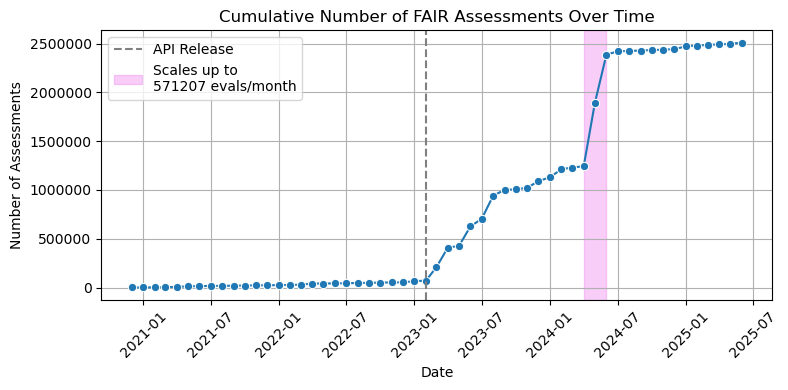

In [ ]:
# concatenate year and month into a single datetime column
results['date'] = results.apply(lambda row: datetime(int(row['year']), int(row['month']), 1), axis=1)
# compute the cumulative sum of the number of assessments
results["nbEval"] = results["nbEval"].astype(int)
results = results.sort_values(by='date')    
# compute the cumulative sum of the number of assessments
results['cumSum'] = results['nbEval'].cumsum()
display(results)


# plot a seaborn cumulative sum of the number of FAIR assessments over time
plt.figure(figsize=(8, 4))
sns.lineplot(data=results, x='date', y='cumSum', marker='o')
# insert a star marker for the 26th point
plt.axvline(x=results['date'].iloc[26], color='gray', linestyle='--', label='API Release')
# insert a filled rectangle including the 40th and 42th points
mean_peak = (results["nbEval"].iloc[41] + results["nbEval"].iloc[42]) / 2
mean_peak = int(mean_peak)
plt.axvspan(results['date'].iloc[40], results['date'].iloc[42], color='orange', alpha=0.4, label=f'Scales up to\n{mean_peak} evals/month')
# insert a vertical line for the
plt.legend()    
plt.grid(True)
plt.title('Cumulative Number of FAIR Assessments Over Time')
plt.xlabel('Date')
plt.xticks(rotation=45)
# dont use scientific notation for y-axis
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.ylabel('Number of Assessments')
plt.savefig('cumulative_fair_assessments_over_time.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [231]:
# 
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
prefix : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT DISTINCT ?target (count(?s) as ?nbEval) WHERE {
  ?s rdf:type dqv:QualityMeasurement ;
     dqv:isMeasurementOf :F2A ;
     dqv:computedOn ?target .
#  FILTER (?nbEval >= 2)
} 
GROUP BY ?target
ORDER BY desc(?nbEval)
"""

## Multi-evaluated resources over time

In [232]:
# a sparql query to list values in a time frame of 30 days 
query = """
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?computedOn (AVG(xsd:decimal(?value)) AS ?meanValue) WHERE {
    ?s rdf:type dqv:QualityMeasurement ;
        prov:generatedAtTime ?time ;
        dqv:value ?value ;
        dqv:isMeasurementOf ?principle ;
        dqv:computedOn ?computedOn .
    FILTER (?principle NOT IN (:None))
    FILTER (?time >= "2024-01-01T00:00:00Z"^^xsd:dateTime && ?time <= "2024-01-31T23:59:59Z"^^xsd:dateTime)
} 
GROUP BY ?computedOn
ORDER BY desc(?meanValue)
"""

results = execute_sparql_query(query)
results

KeyboardInterrupt: 

In [ ]:
# iterate over all month of 2022 and generate a start and end date in xsd:dateTime format

YEAR = 2025

start_date = datetime(YEAR, 1, 1)
end_date = datetime(YEAR, 5, 31)
date_range = pd.date_range(start=start_date, end=end_date, freq='30D', inclusive='both')
date_range = date_range.strftime('%Y-%m-%dT%H:%M:%SZ').tolist() 

# generate a pair of start and end date for each month
date_pairs = [(date, (pd.to_datetime(date) + timedelta(days=30)).strftime('%Y-%m-%dT%H:%M:%SZ')) for date in date_range]    

for start, end in tqdm(date_pairs):
    # year_month = pd.to_datetime(start).strftime("%Y-%m")
    # if f"{year_month}.csv" in os.listdir("."):
    #     print(f"File {year_month}.csv already exists, skipping...")
    #     i += 1
    #     continue
    print(f"Start: {start}, End: {end}")

    query = f"""
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?computedOn (AVG(xsd:decimal(?value)) AS ?meanValue) WHERE {{
    ?s rdf:type dqv:QualityMeasurement ;
        prov:generatedAtTime ?time ;
        dqv:value ?value ;
        dqv:isMeasurementOf ?principle ;
        dqv:computedOn ?computedOn .
    FILTER (?principle NOT IN (:None))
    FILTER (?time >= "{start}"^^xsd:dateTime && ?time <= "{end}"^^xsd:dateTime)
}}
GROUP BY ?computedOn
ORDER BY desc(?meanValue)
"""
    results = execute_sparql_query(query)
    # extract the year, month and day from the start date
    y_m_d = pd.to_datetime(start).strftime("%Y-%m-%d")
    results.to_csv(f"{y_m_d}.csv", index=False)

  0%|          | 0/6 [00:00<?, ?it/s]

Start: 2025-01-01T00:00:00Z, End: 2025-01-31T00:00:00Z
Start: 2025-01-31T00:00:00Z, End: 2025-03-02T00:00:00Z
Start: 2025-03-02T00:00:00Z, End: 2025-04-01T00:00:00Z
Start: 2025-04-01T00:00:00Z, End: 2025-05-01T00:00:00Z
Start: 2025-05-01T00:00:00Z, End: 2025-05-31T00:00:00Z
Start: 2025-05-31T00:00:00Z, End: 2025-06-30T00:00:00Z


In [ ]:
# list all results_*.csv files
dfs = []

for file in sorted(os.listdir('.')):
    if file.startswith(f'{YEAR}-') and file.endswith('.csv'):
        # load the file into a DataFrame
        df = pd.read_csv(file)
        dfs.append((file, df))
        print(f"Loaded {file} with shape {df.shape}")
        # if len(dfs) > 4:
        #     break


# merge all DataFrames in dfs on computedOn and keep raw if there is no value
# using the first DataFrame as the base
merged_df = dfs[0][1]
merged_df = merged_df.rename(columns={'meanValue': 'meanValue_'+dfs[0][0]})
display(merged_df.head())
i = 1
for index, df in dfs[1:]:
    df = df.rename(columns={'meanValue': 'meanValue_'+index})
    print(f"Merging {left_suffix} with {right_suffix}")
    merged_df = merged_df.merge(
        df, on="computedOn", how="outer", suffixes=('', f'_{index}')
    )
    i += 1

# a function to scale the meanValue columns to percentage for each row
def scale_mean_values(row):
    mean_value_cols = [col for col in row.index if col.startswith('meanValue')]
    for col in mean_value_cols:
        if pd.notna(row[col]):
            # scale the value to percentage
            row[col] = round(row[col] * 100 / 2, 2)
        else:
            row[col] = np.nan
    return row
merged_df = merged_df.apply(scale_mean_values, axis=1)

display(merged_df.head())

# set the first column as index
merged_df.set_index('computedOn', inplace=True)

# list rows with only one non nan value
eval_counts = merged_df.notna().sum(axis=1)
# display(eval_counts)
rows_with_one_value = merged_df[eval_counts == 1]
# display(rows_with_one_value.head())

# remove rows with only one non nan value
merged_df = merged_df[eval_counts > 1]
# print(merged_df.shape)
# print(merged_df.describe())


df_melted = merged_df.reset_index().melt(
    id_vars="computedOn", var_name="Observation", value_name="Value"
)

# sort the melted DataFrame by computedOn and Observation
df_melted.sort_values(by=["computedOn", "Observation"], inplace=True)

display(df_melted.head())

Loaded 2025-01-01.csv with shape (1513, 2)
Loaded 2025-01-31.csv with shape (470, 2)
Loaded 2025-03-02.csv with shape (343, 2)
Loaded 2025-04-01.csv with shape (240, 2)
Loaded 2025-05-01.csv with shape (226, 2)
Loaded 2025-05-31.csv with shape (668, 2)


,computedOn,meanValue_2025-01-01.csv
0,http://www.jeeng.net/pdf-119521-49555?filename...,2.0
1,https://doi.org/10.32370/IA_2021_06_17,2.0
2,https://doi.org/10.32851/2226-0099.2020.111.27,2.0
3,https://doi.org/10.32851/2226-0099.2023.130.56,2.0
4,https://doi.org/10.37394/232015.2022.18.98,2.0


Merging 2023-04-01.csv with 2023-05-01.csv
Merging 2023-04-01.csv with 2023-05-01.csv
Merging 2023-04-01.csv with 2023-05-01.csv
Merging 2023-04-01.csv with 2023-05-01.csv
Merging 2023-04-01.csv with 2023-05-01.csv


,computedOn,meanValue_2025-01-01.csv,meanValue_2025-01-31.csv,meanValue_2025-03-02.csv,meanValue_2025-04-01.csv,meanValue_2025-05-01.csv,meanValue_2025-05-31.csv
0,http://www.jeeng.net/pdf-119521-49555?filename...,100.0,NaN,NaN,NaN,NaN,NaN
1,https://doi.org/10.32370/IA_2021_06_17,100.0,NaN,NaN,NaN,NaN,NaN
2,https://doi.org/10.32851/2226-0099.2020.111.27,100.0,NaN,NaN,NaN,NaN,NaN
3,https://doi.org/10.32851/2226-0099.2023.130.56,100.0,NaN,NaN,NaN,NaN,NaN
4,https://doi.org/10.37394/232015.2022.18.98,100.0,NaN,NaN,NaN,NaN,NaN


,computedOn,Observation,Value
69,http://bio.tools/bwa,meanValue_2025-01-01.csv,NaN
163,http://bio.tools/bwa,meanValue_2025-01-31.csv,NaN
257,http://bio.tools/bwa,meanValue_2025-03-02.csv,50.00
351,http://bio.tools/bwa,meanValue_2025-04-01.csv,50.00
445,http://bio.tools/bwa,meanValue_2025-05-01.csv,77.14


/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_21011/1325780959.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


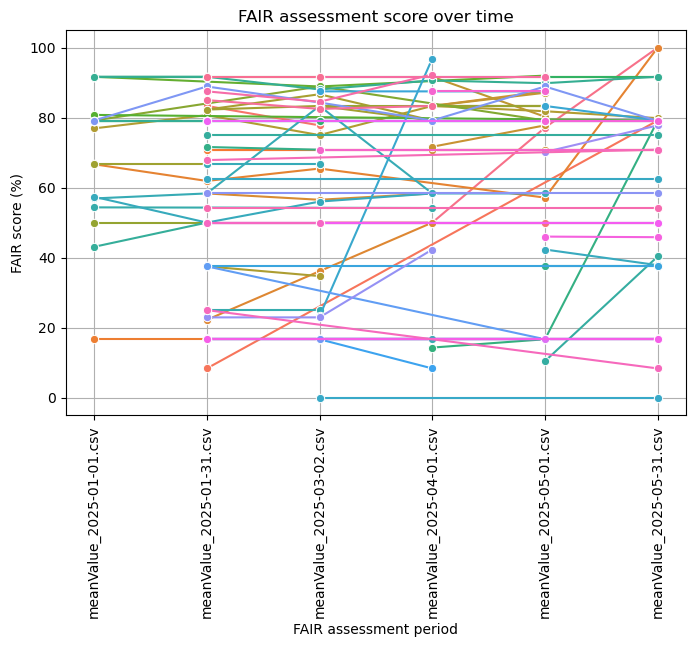

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot the meanValue for each computedOn with a seaborn lineplot
import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 5))
sns.lineplot(data=df_melted, x="Observation", y="Value", hue="computedOn", marker="o")
plt.title("Line Plot of Observations Across Measures")
#plt.ylim(0, 2)
#rename the x-axis to "Observation"
plt.xlabel("FAIR assessment period")
plt.ylabel("FAIR score (%)")
plt.xticks(rotation=45)
#plt.axhline(y=100, color='r', linestyle='--', label='100% Threshold')
#plt.axhline(y=0, color='g', linestyle='--', label='0% Threshold')
#plt.fill_between(df_melted['Observation'], 0, 100, color='gray', alpha=0.1, label='Valid Range (0% - 100%)')
plt.title("FAIR assessment score over time")

plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)
plt.legend().remove()
plt.show()
plt.savefig(f"fair_assessment_score_over_time_{YEAR}.png", dpi=300, bbox_inches='tight')


## ✅ Most evaluated domains

In [170]:
Ymin = 2021
Ymax = 2025

query = f"""
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dqv: <http://www.w3.org/ns/dqv#>
PREFIX prov: <http://www.w3.org/ns/prov#>
PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

SELECT ?computedOn (count(?s) AS ?nb) WHERE {{
    ?s rdf:type dqv:QualityMeasurement ;
        prov:generatedAtTime ?time ;
        dqv:isMeasurementOf ?principle ;
        dqv:computedOn ?computedOn .
    FILTER (?principle NOT IN (:None))
    FILTER (?time >= "{Ymin}-01-01T00:00:00Z"^^xsd:dateTime && ?time <= "{Ymax}-12-31T23:59:59Z"^^xsd:dateTime)
}} 
GROUP BY ?computedOn
ORDER BY desc(?nb)
"""

results = execute_sparql_query(query)
results

,computedOn,nb
0,http://orkg.org/orkg/class/Resource,35856
1,https://www.pxweb.bfs.admin.ch/Default.aspx?,8688
2,https://github.com/BFO-ontology/BFO/blob/maste...,6298
3,https://raw.githubusercontent.com/frmichel/tax...,5630
4,https://data.inrae.fr/dataset.xhtml?persistent...,4985
...,...,...
102168,https://www.fr.ch/sej/vie-quotidienne/structur...,1
102169,https://www.geysse.com/,1
102170,https://www.scidb.cn/en/detail?dataSetId=72062...,1
102171,https://zenodo.org/record/7655308#.ZBEd9JHMKUk,1


In [171]:
from urllib.parse import urlparse

# for each row in the result dataframe, extract the domain of each URL
def extract_domain(url):
    if pd.isna(url):
        return None
    domain = urlparse(url).netloc
    return domain

results['domain'] = results['computedOn'].apply(extract_domain)
results

,computedOn,nb,domain
0,http://orkg.org/orkg/class/Resource,35856,orkg.org
1,https://www.pxweb.bfs.admin.ch/Default.aspx?,8688,www.pxweb.bfs.admin.ch
2,https://github.com/BFO-ontology/BFO/blob/maste...,6298,github.com
3,https://raw.githubusercontent.com/frmichel/tax...,5630,raw.githubusercontent.com
4,https://data.inrae.fr/dataset.xhtml?persistent...,4985,data.inrae.fr
...,...,...,...
102168,https://www.fr.ch/sej/vie-quotidienne/structur...,1,www.fr.ch
102169,https://www.geysse.com/,1,www.geysse.com
102170,https://www.scidb.cn/en/detail?dataSetId=72062...,1,www.scidb.cn
102171,https://zenodo.org/record/7655308#.ZBEd9JHMKUk,1,zenodo.org


In [173]:
results['nb'] = results['nb'].astype(int)  # Convert 'nb' column

domain_counts = results.groupby("domain")["nb"].sum().reset_index()
# sort the domain counts in descending order
domain_counts = domain_counts.sort_values(by="nb", ascending=False)
domain_counts.to_csv(f"domain_counts_{Ymin}_{Ymax}.csv", index=False)
domain_counts

,domain,nb
1801,www.data.gv.at,742830
1191,orkg.org,522600
526,doi.org,452271
1628,ws.cso.ie,194589
96,arxiv.org,74195
...,...,...
1613,webfs.oecd.org,1
1893,www.geodata.cn,1
691,gctype.wdcm.org,1
1673,www.archiviodistato.prato.it,1


/var/folders/x1/d1nyvpvs0td0htxzsv9x6ggw0000gn/T/ipykernel_77785/3196671872.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="nb", y="domain", data=domain_counts.head(K), palette="viridis")


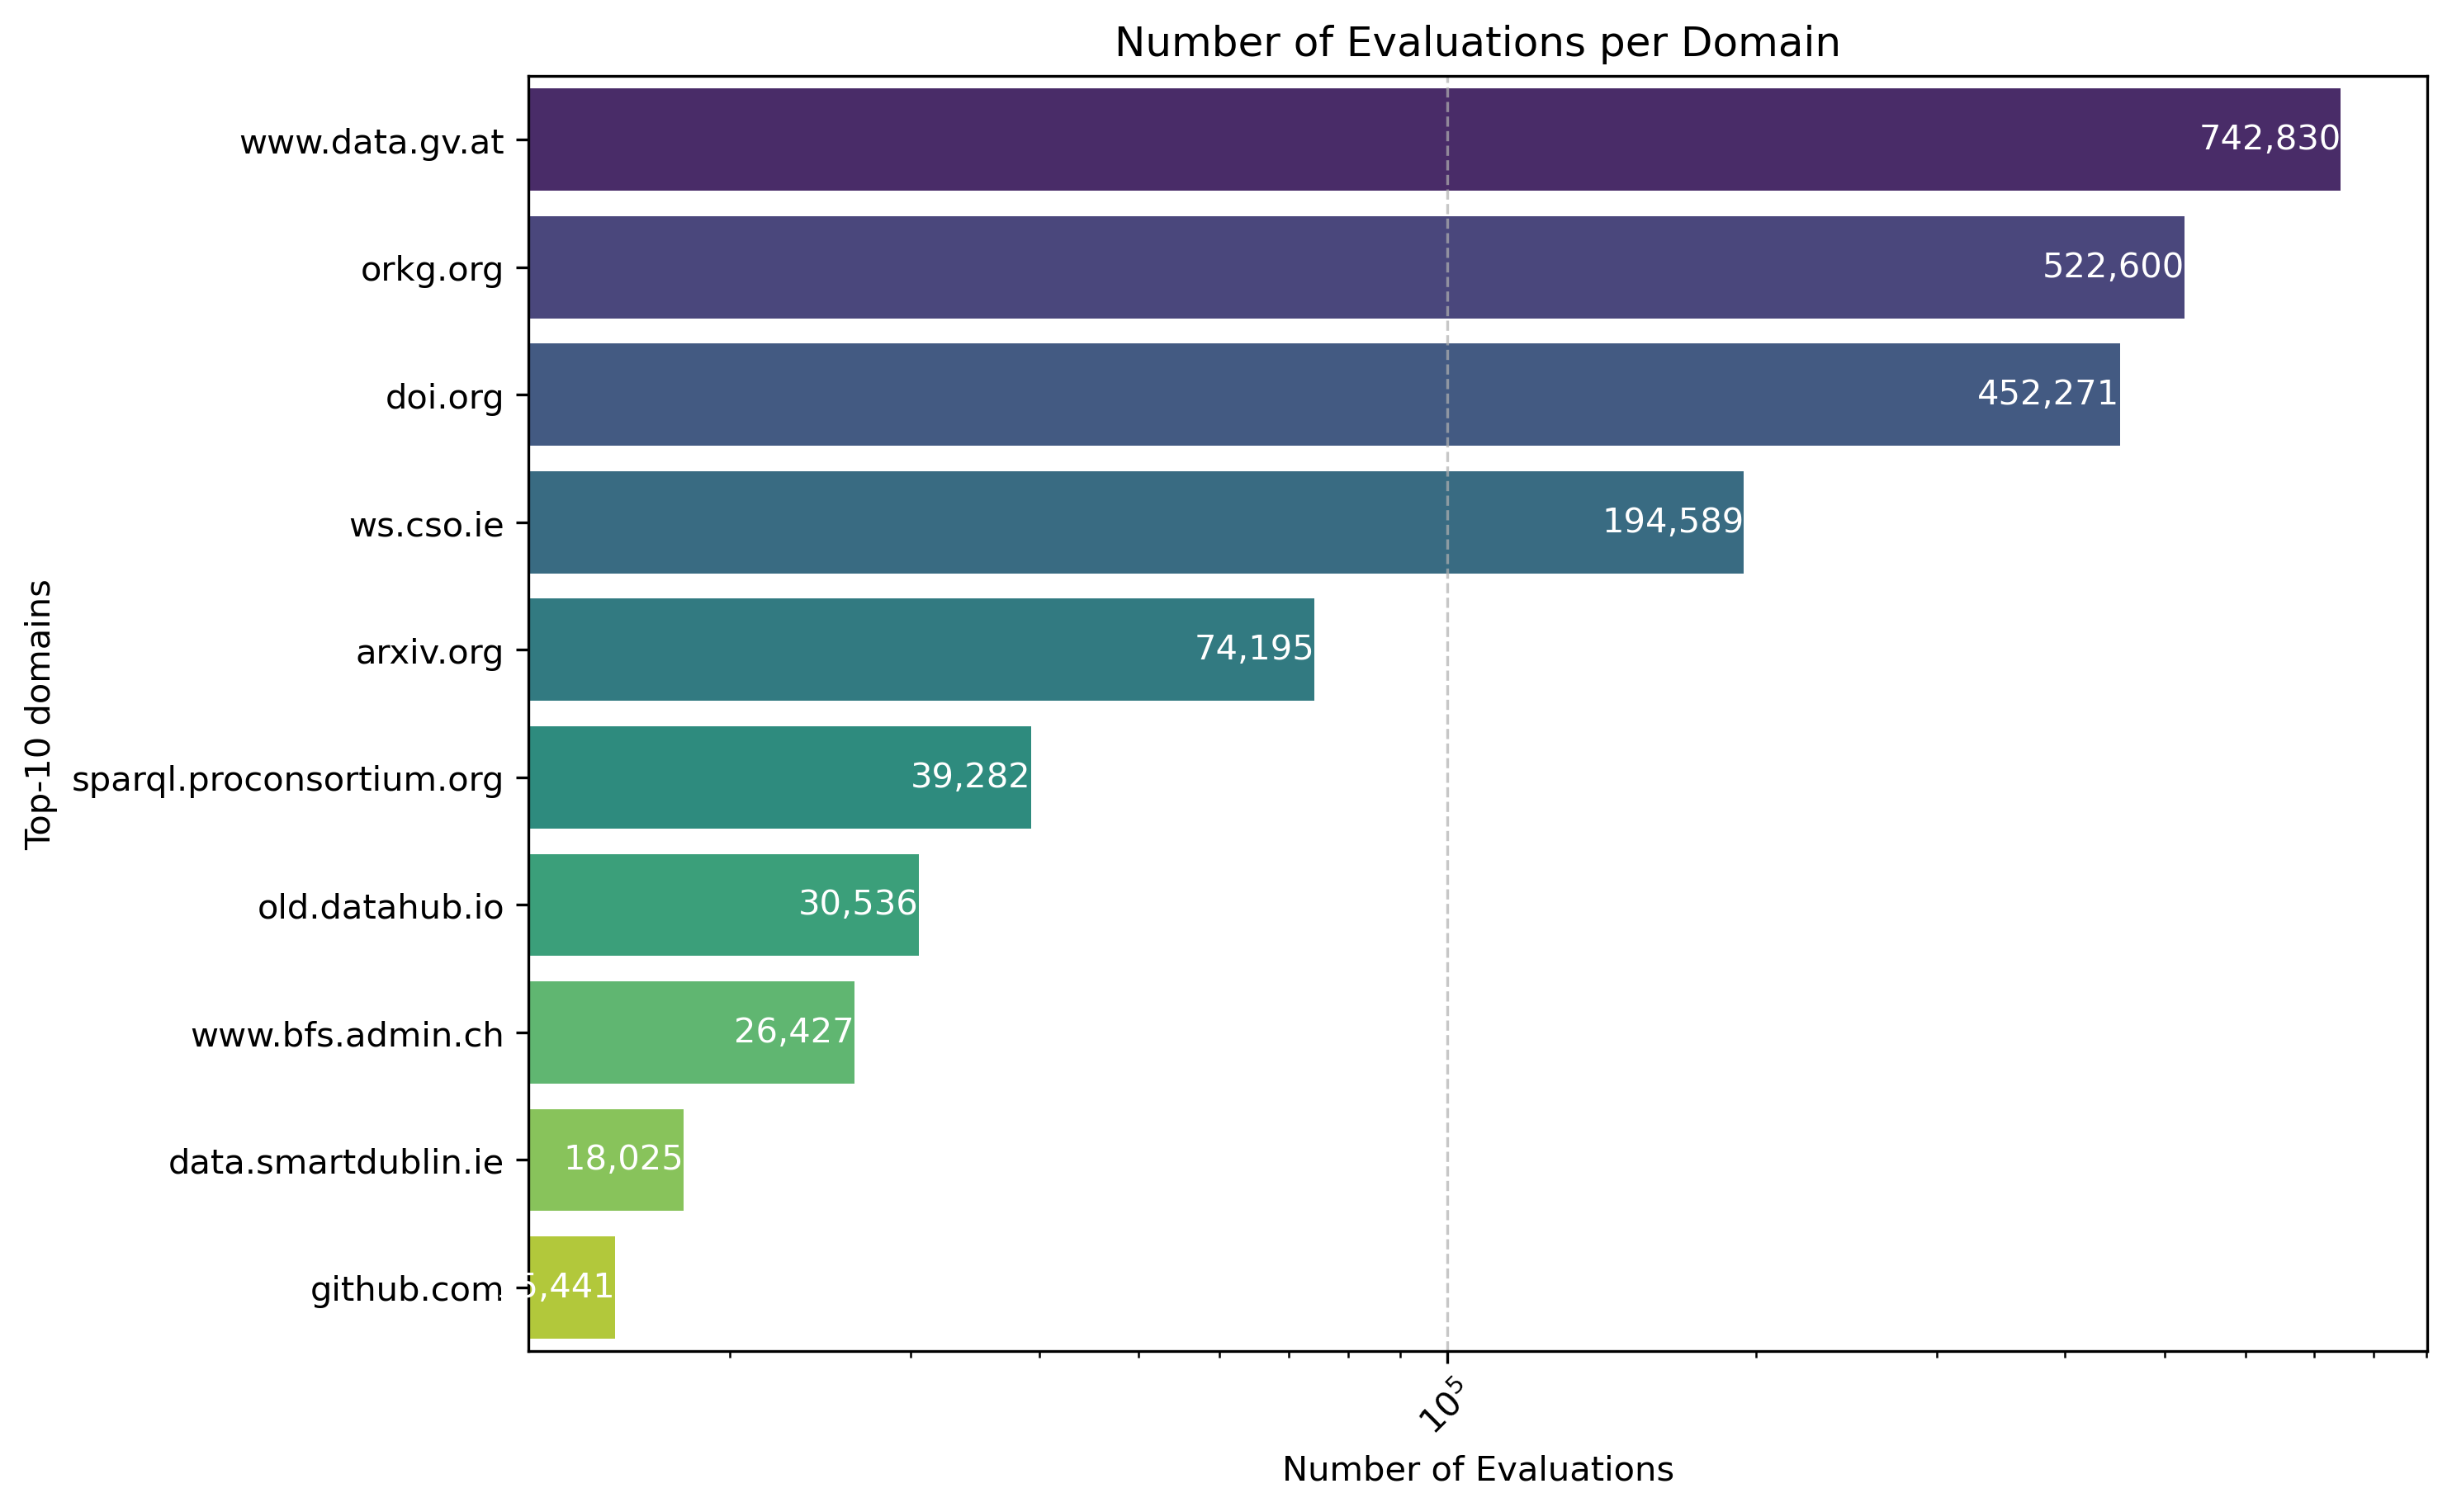

In [184]:
# plot the number of evaluations per domain by using seaborn,
# use an horizontal bar plot, sort by number of evaluations, use a log scale for the x-axis
plt.figure(figsize=(10, 6), dpi=300)
K = 10
# domain_counts = domain_counts.sort_values(by='nb', ascending=False)
sns.barplot(x="nb", y="domain", data=domain_counts.head(K), palette="viridis")
plt.xscale('log')
# plt.xticks(rotation=45)
# plt.xyticks(rotation=45)
# display the value in the bar in white on the right side of the bar
for index, value in enumerate(domain_counts['nb']):
    plt.text(value, index, f'{value:,}', color='white', va='center', fontsize=10, ha='right')

plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.title('Number of Evaluations per Domain')
plt.xlabel('Number of Evaluations')
plt.ylabel(f'Top-{K} domains')
plt.savefig(f"number_of_evaluations_per_domain_{Ymin}_{Ymax}.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()

## ✅ Overall progress in FAIRification

In [136]:
output = pd.DataFrame()

for YEAR in tqdm(range(2021,2026)):
    query = f"""
    PREFIX schema: <http://schema.org/>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
    PREFIX dqv: <http://www.w3.org/ns/dqv#>
    PREFIX prov: <http://www.w3.org/ns/prov#>
    PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

    SELECT ?value (count(?s) AS ?nb) WHERE {{
        ?s rdf:type dqv:QualityMeasurement ;
            prov:generatedAtTime ?time ;
            dqv:isMeasurementOf ?principle ;
            dqv:value ?value .
        FILTER (?principle NOT IN (:None))
        FILTER (?time >= "{YEAR}-01-01T00:00:00Z"^^xsd:dateTime && ?time <= "{YEAR}-12-31T23:59:59Z"^^xsd:dateTime)
    }} 
    GROUP BY ?value
    ORDER BY desc(?nb)
    """

    results = execute_sparql_query(query)
    # change type of value to int
    results['value'] = results['value'].astype(int)
    results['nb'] = results['nb'].astype(int)

    row = pd.DataFrame(
        {
            "year": [YEAR],
            "success": results[results["value"] > 0]["nb"].sum(),
            "failure": results[results["value"] <= 0]["nb"].sum(),
        }
    )
    output = pd.concat([output, row], ignore_index=True)

# save the output to a csv file
output["success_percent"] = (
    output["success"] / (output["success"] + output["failure"]) * 100
)
output["failure_percent"] = (
    output["failure"] / (output["success"] + output["failure"]) * 100
)
output.to_csv("success_failure_evolution_FAIR.csv", index=False)

  0%|          | 0/5 [00:00<?, ?it/s]

<function matplotlib.pyplot.show(close=None, block=None)>

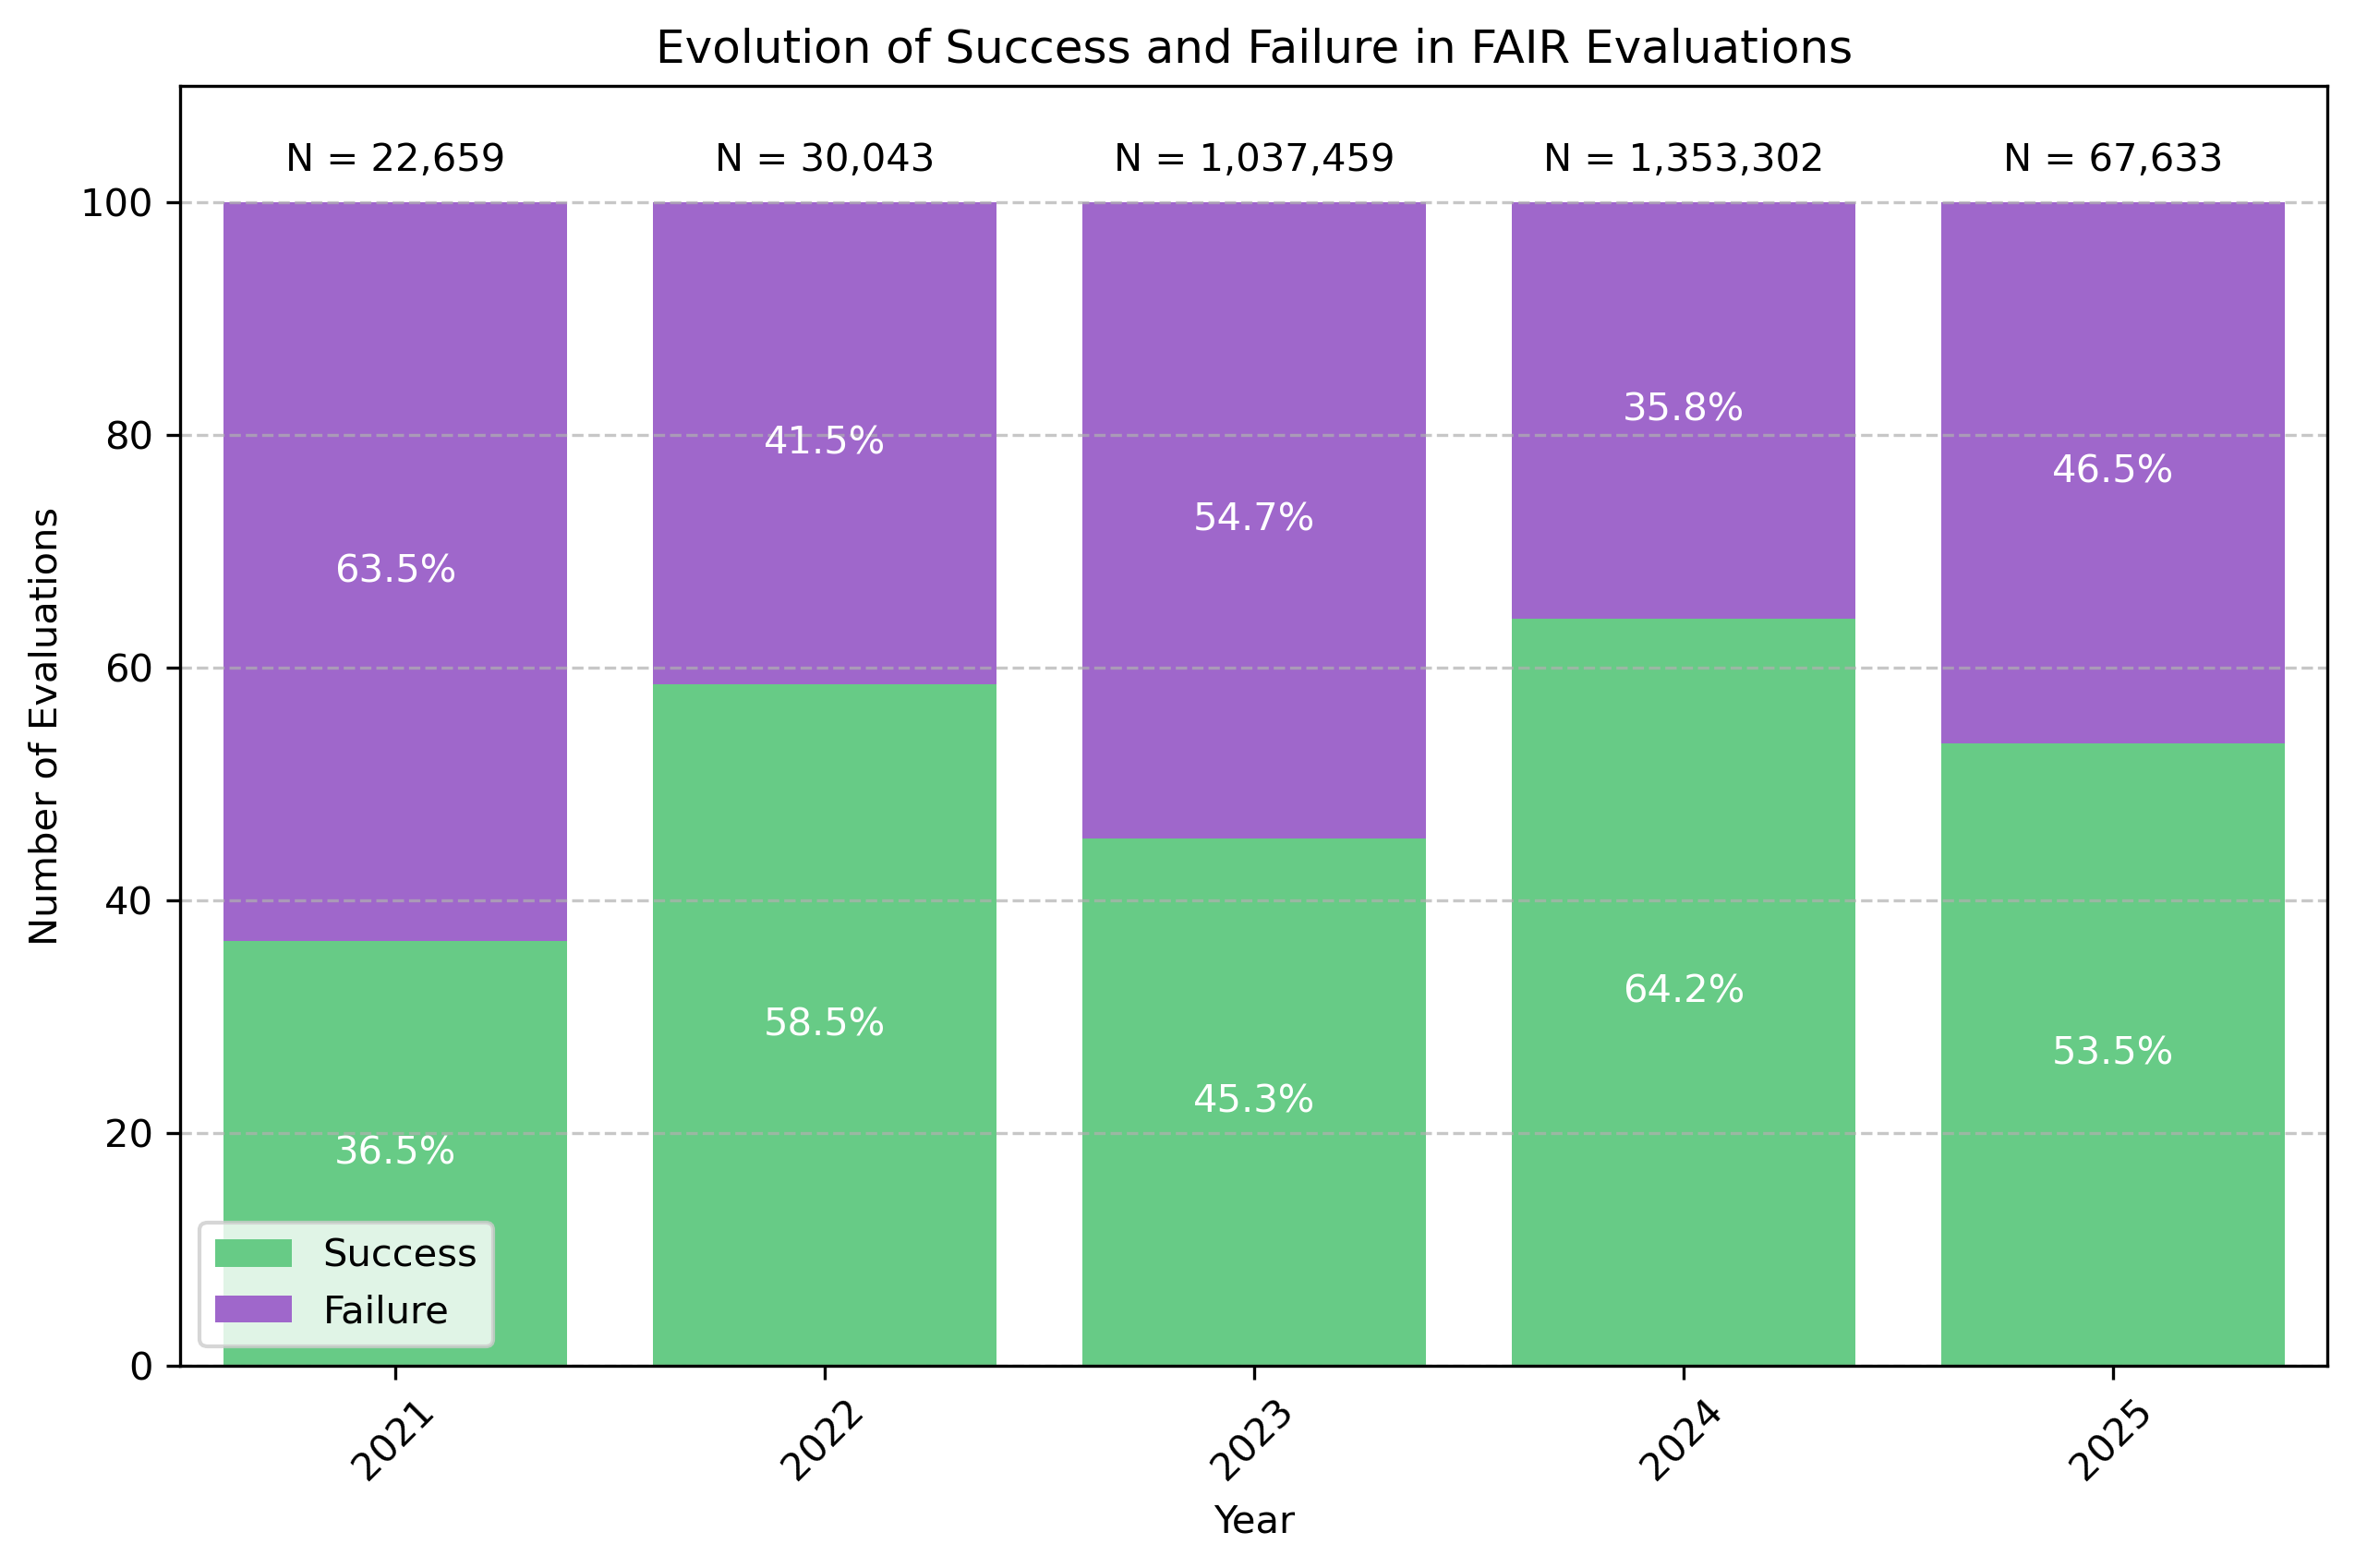

In [137]:
# plot a stacked bar chart with seaborn of success and failure percentage over the years
plt.figure(figsize=(10, 6), dpi=300)
sns.barplot(
    data=output,
    x="year",
    y="success_percent",
    label="Success",
    color=sns.color_palette("hls", 8)[3],
)
sns.barplot(
    data=output,
    x="year",
    y="failure_percent",
    label="Failure",
    color=sns.color_palette("hls", 8)[6],
    bottom=output["success_percent"],
)
# insert text inside each percent stacked bar in white
for index, row in output.iterrows():
    plt.text(
        x=index,
        y=row['success_percent'] / 2,
        s=f"{row['success_percent']:.1f}%",
        color='white',
        ha='center',
        va='center'
    )
    plt.text(
        x=index,
        y=row['success_percent'] + row['failure_percent'] / 2,
        s=f"{row['failure_percent']:.1f}%",
        color='white',
        ha='center',
        va='center'
    )

# insert the total number of evaluation for each year in black on the top
for index, row in output.iterrows():
    total = row['success'] + row['failure']
    plt.text(
        x=index,
        y=row["success_percent"] + row["failure_percent"] + 2,
        s=f"N = {int(total):,}",
        color="black",
        ha="center",
        va="bottom",
    )

# set the y scale to cover also the 120 value
plt.ylim(0, 110)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Number of Evaluations")
plt.title("Evolution of Success and Failure in FAIR Evaluations")

plt.savefig("success_failure_evolution.png", dpi=300, format='pdf', bbox_inches='tight')
plt.show

#### Progress for F sub-principles

In [164]:
sub_principles = {
    "F": [
        ":F1",
        ":F1A",
        ":F1B",
        ":F2",
        ":F2A",
        ":F2B",
        ":F3",
        ":F4",
    ],
    "A": [":A1.1", ":A1.2"],
    "I": [":I1", ":I2", ":I3"],
    "R": [":R1.1", ":R1.2", ":R1.3"],
}

for k in tqdm(sub_principles.keys()):
    output = pd.DataFrame()
    for YEAR in tqdm(range(2021, 2026)):
        query = f"""
        PREFIX schema: <http://schema.org/>
        PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
        PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
        PREFIX dqv: <http://www.w3.org/ns/dqv#>
        PREFIX prov: <http://www.w3.org/ns/prov#>
        PREFIX : <https://fair-checker.france-bioinformatique.fr/data#> 

        SELECT ?value (count(?s) AS ?nb) WHERE {{
            VALUES ?principle {{ {" ".join(sub_principles[k])} }} 
            ?s rdf:type dqv:QualityMeasurement ;
                prov:generatedAtTime ?time ;
                dqv:isMeasurementOf ?principle ;
                dqv:value ?value .
            FILTER (?time >= "{YEAR}-01-01T00:00:00Z"^^xsd:dateTime && ?time <= "{YEAR}-12-31T23:59:59Z"^^xsd:dateTime)
        }} 
        GROUP BY ?value
        ORDER BY desc(?nb)
        """

        results = execute_sparql_query(query)
        #display(results)
        if len(results) > 0:
            # change type of value to int
            results["value"] = results["value"].astype(int)
            results["nb"] = results["nb"].astype(int)

            row = pd.DataFrame(
                {
                    "year": [YEAR],
                    "success": results[results["value"] > 0]["nb"].sum(),
                    "failure": results[results["value"] <= 0]["nb"].sum(),
                }
            )
            output = pd.concat([output, row], ignore_index=True)
        else:
            row = pd.DataFrame(
                {
                    "year": [YEAR],
                    "success": 0,
                    "failure": 0,
                }
            )
            output = pd.concat([output, row], ignore_index=True)

        # save the output to a csv file
        output["success_percent"] = (
            output["success"] / (output["success"] + output["failure"]) * 100
        )
        output["failure_percent"] = (
            output["failure"] / (output["success"] + output["failure"]) * 100
        )
        #display(output)
    output.to_csv(f"success_failure_evolution_{k}.csv", index=False)
    break

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

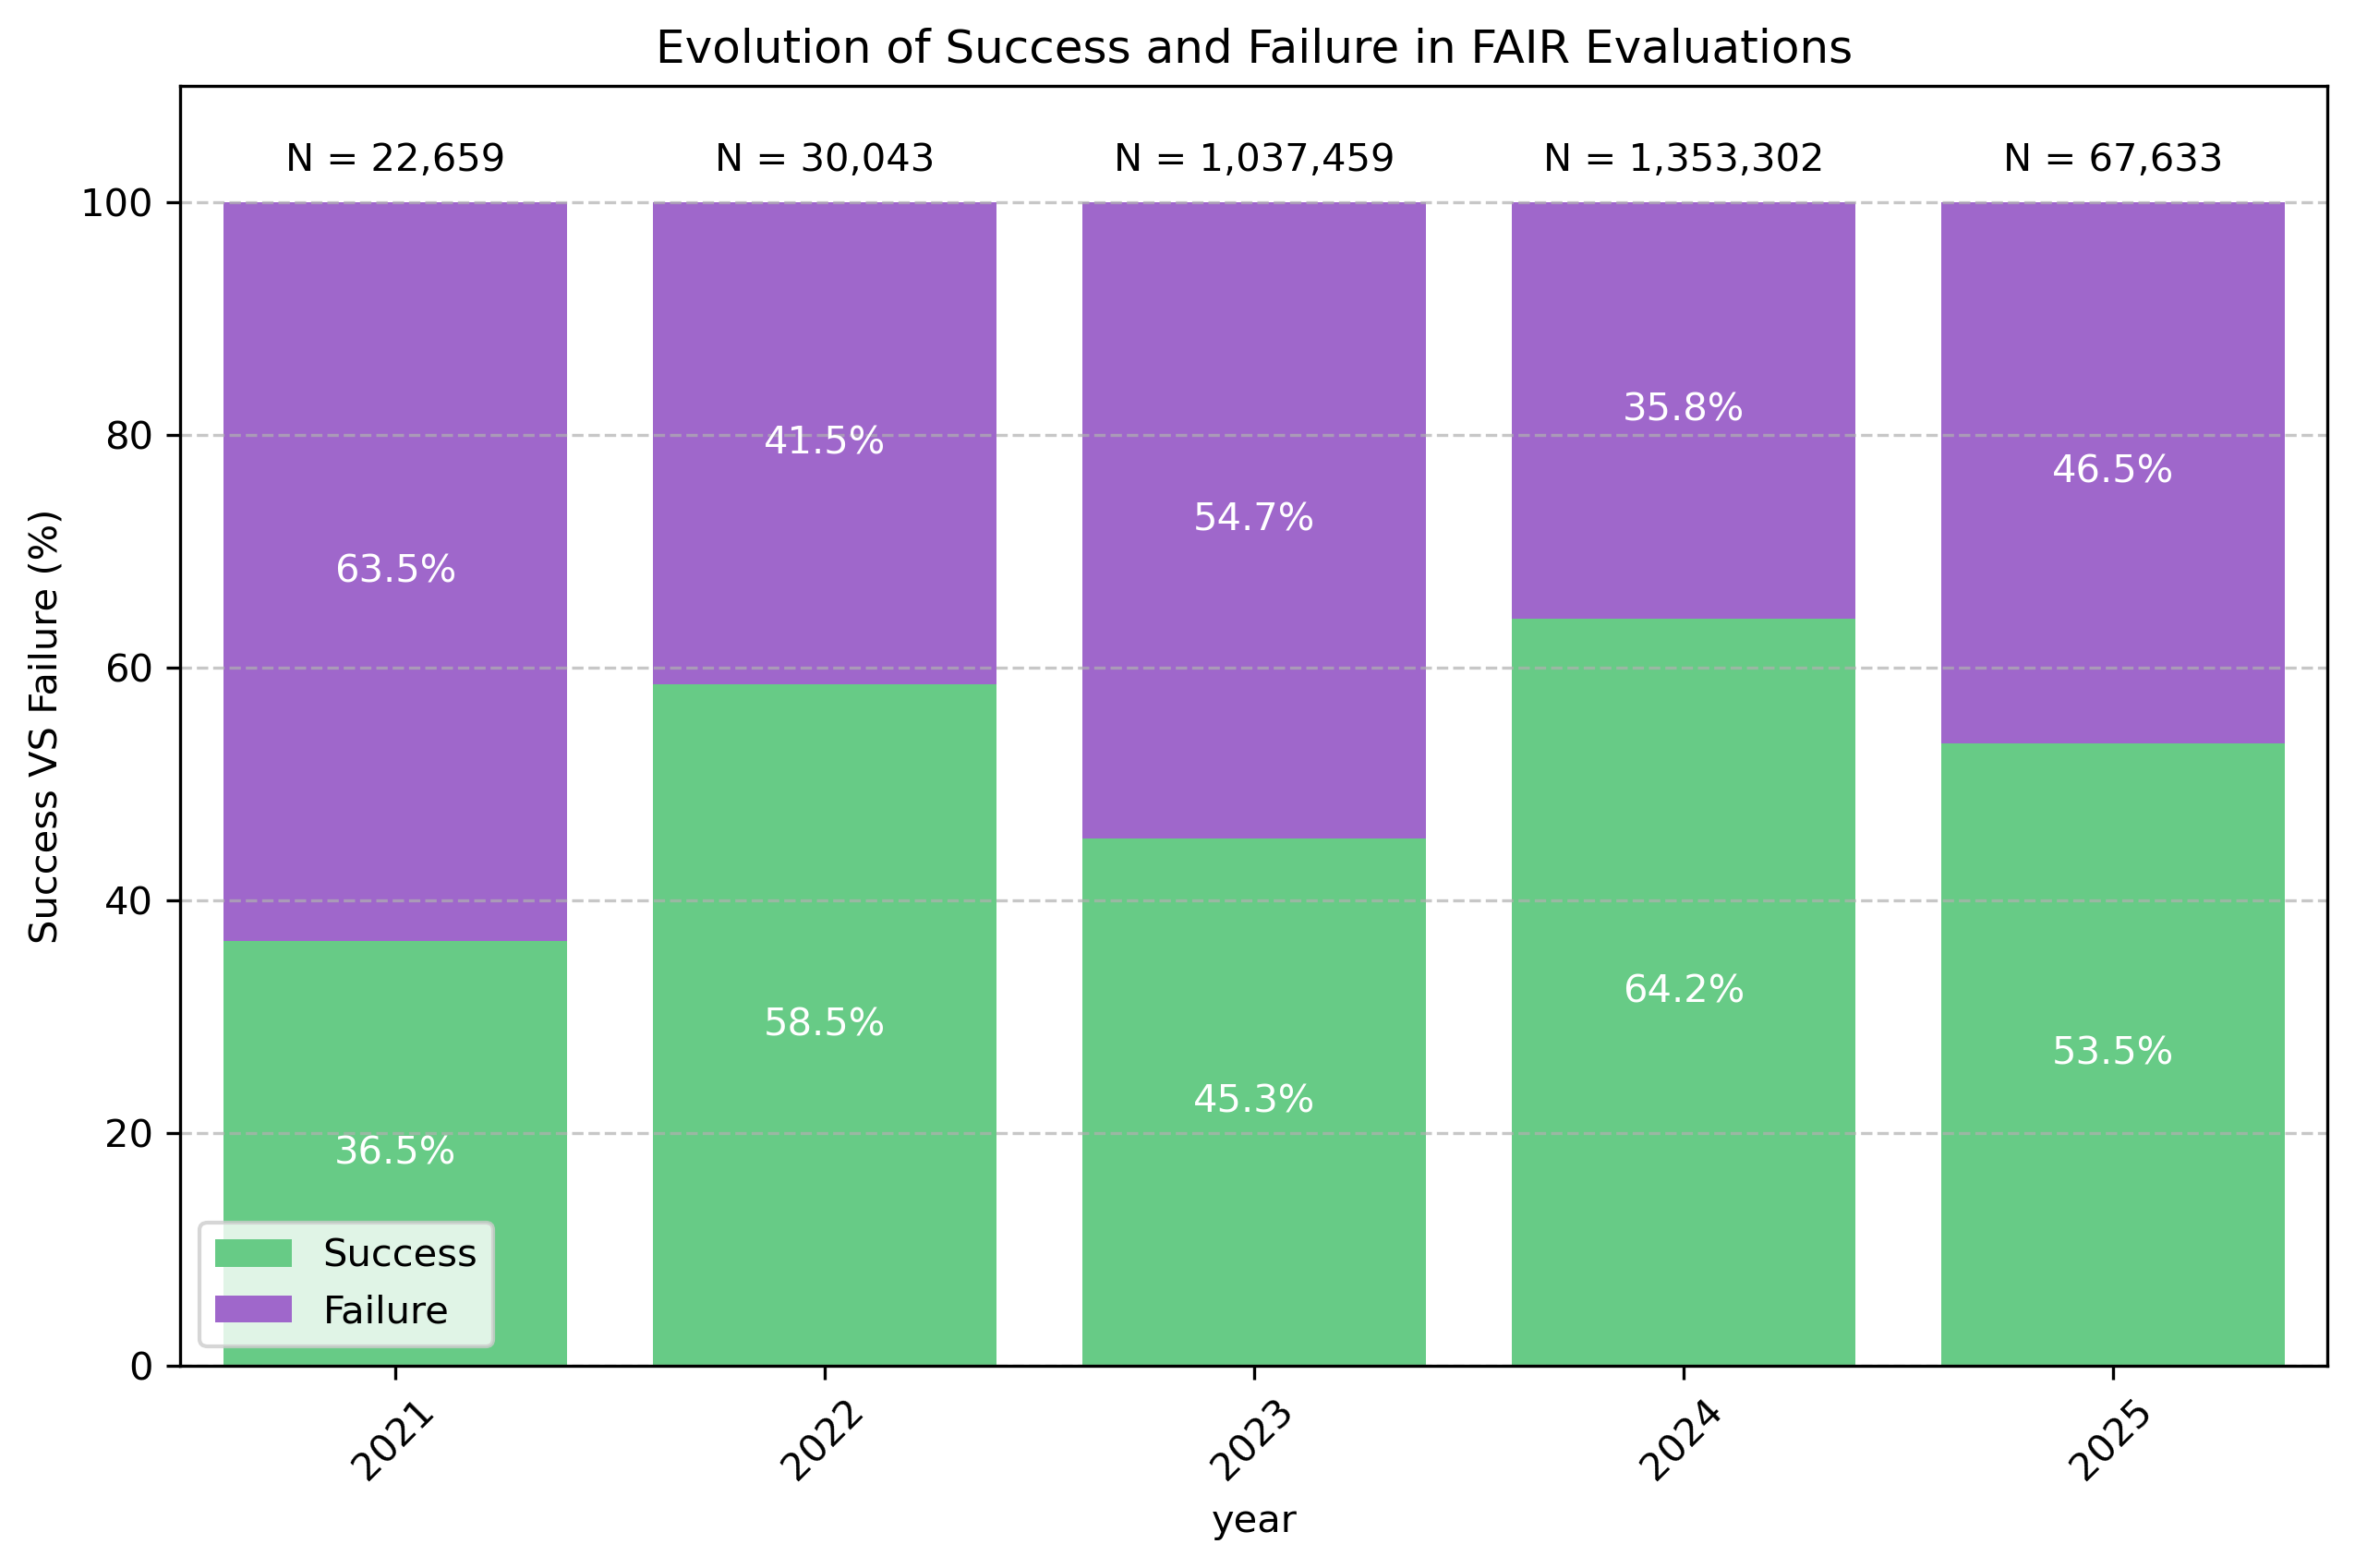

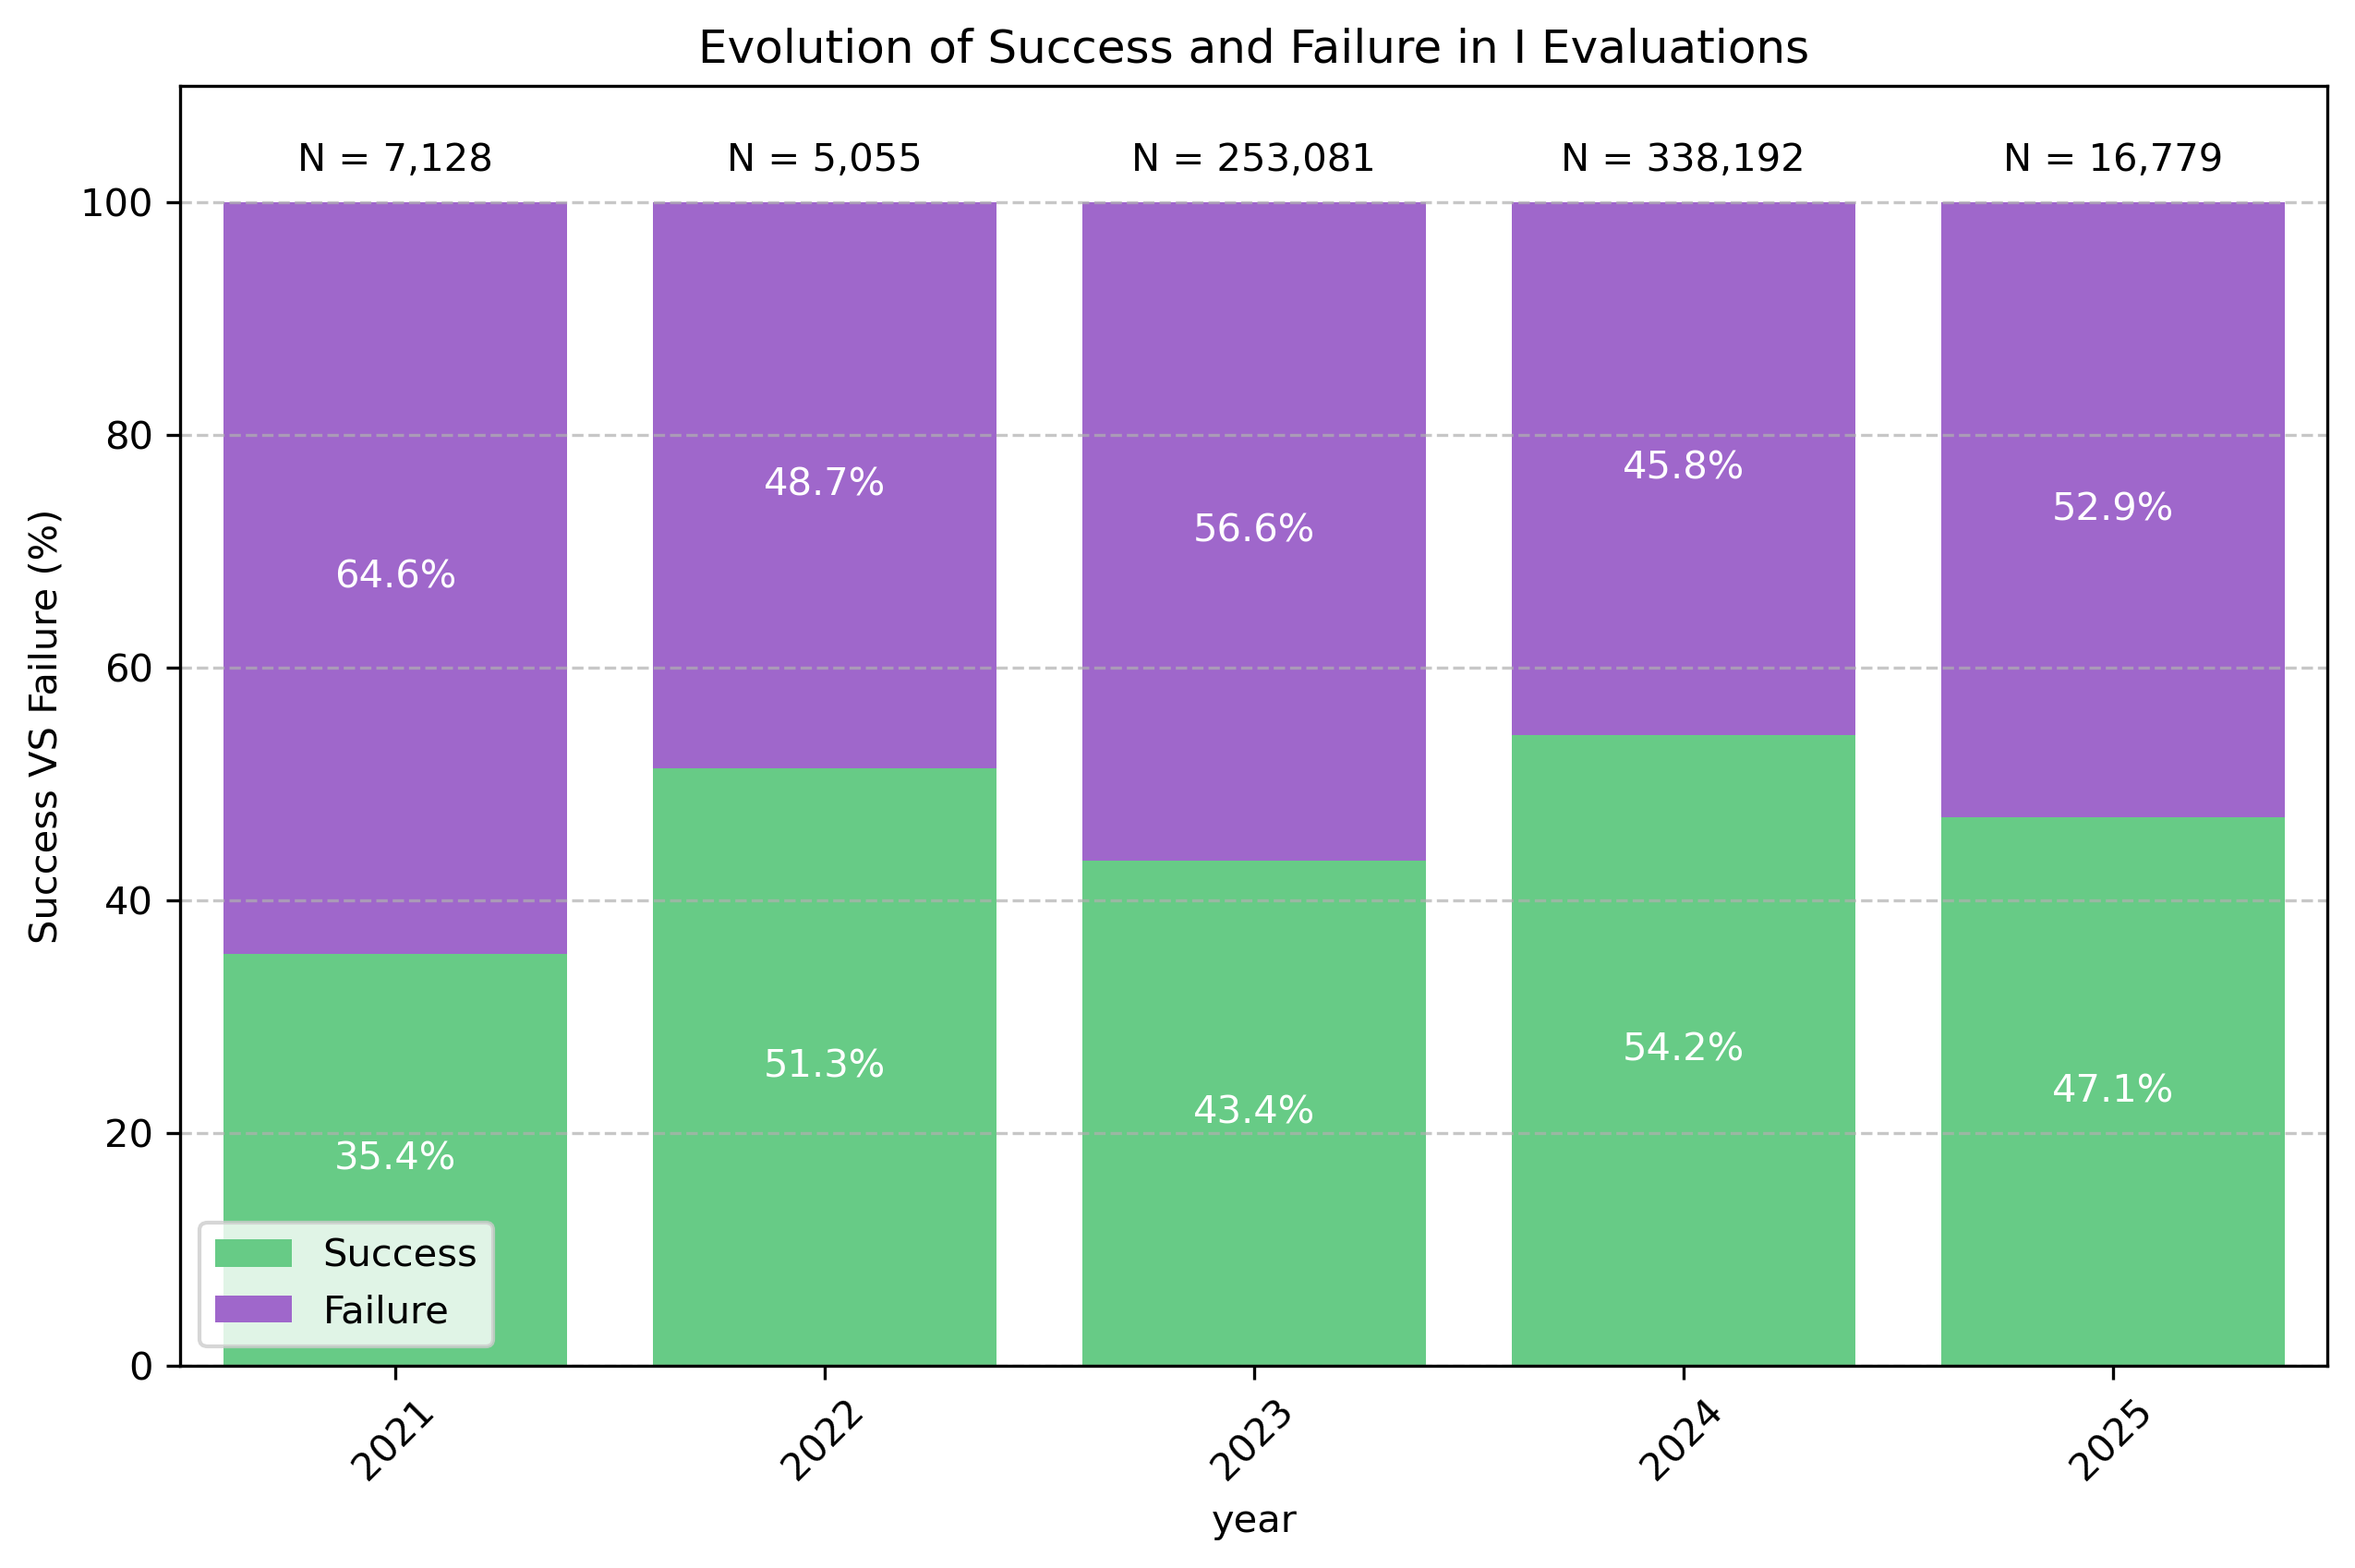

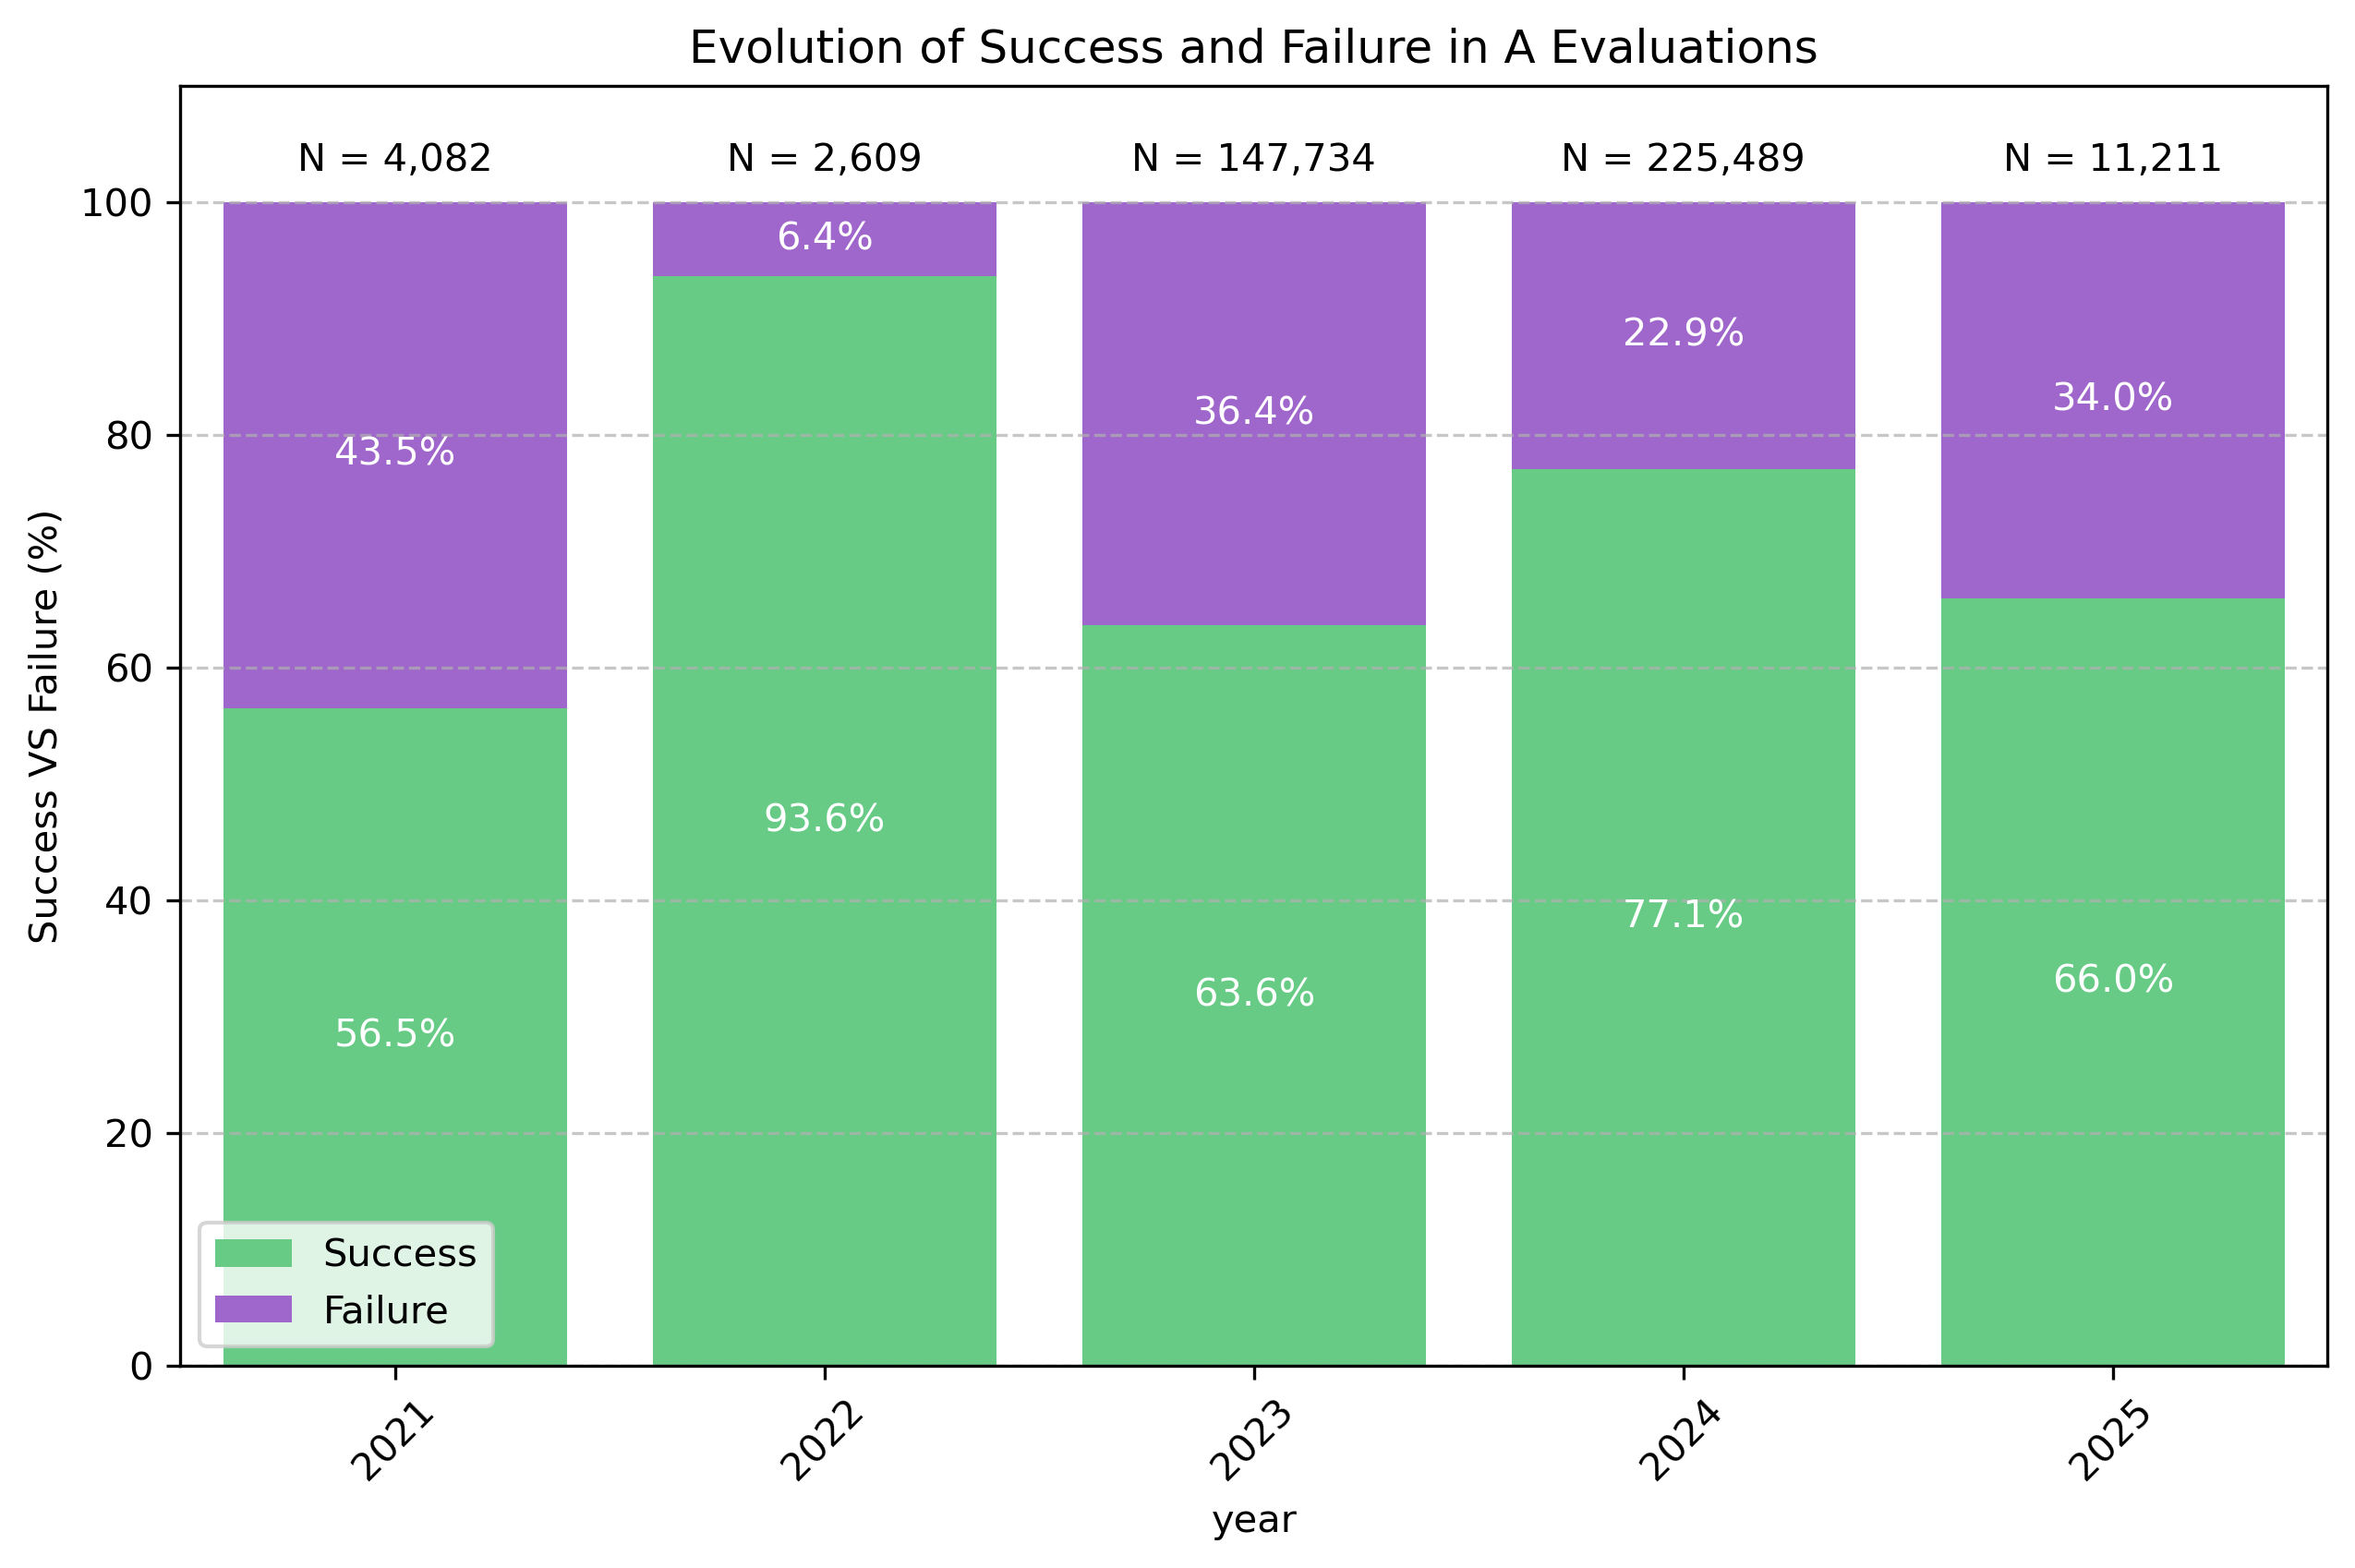

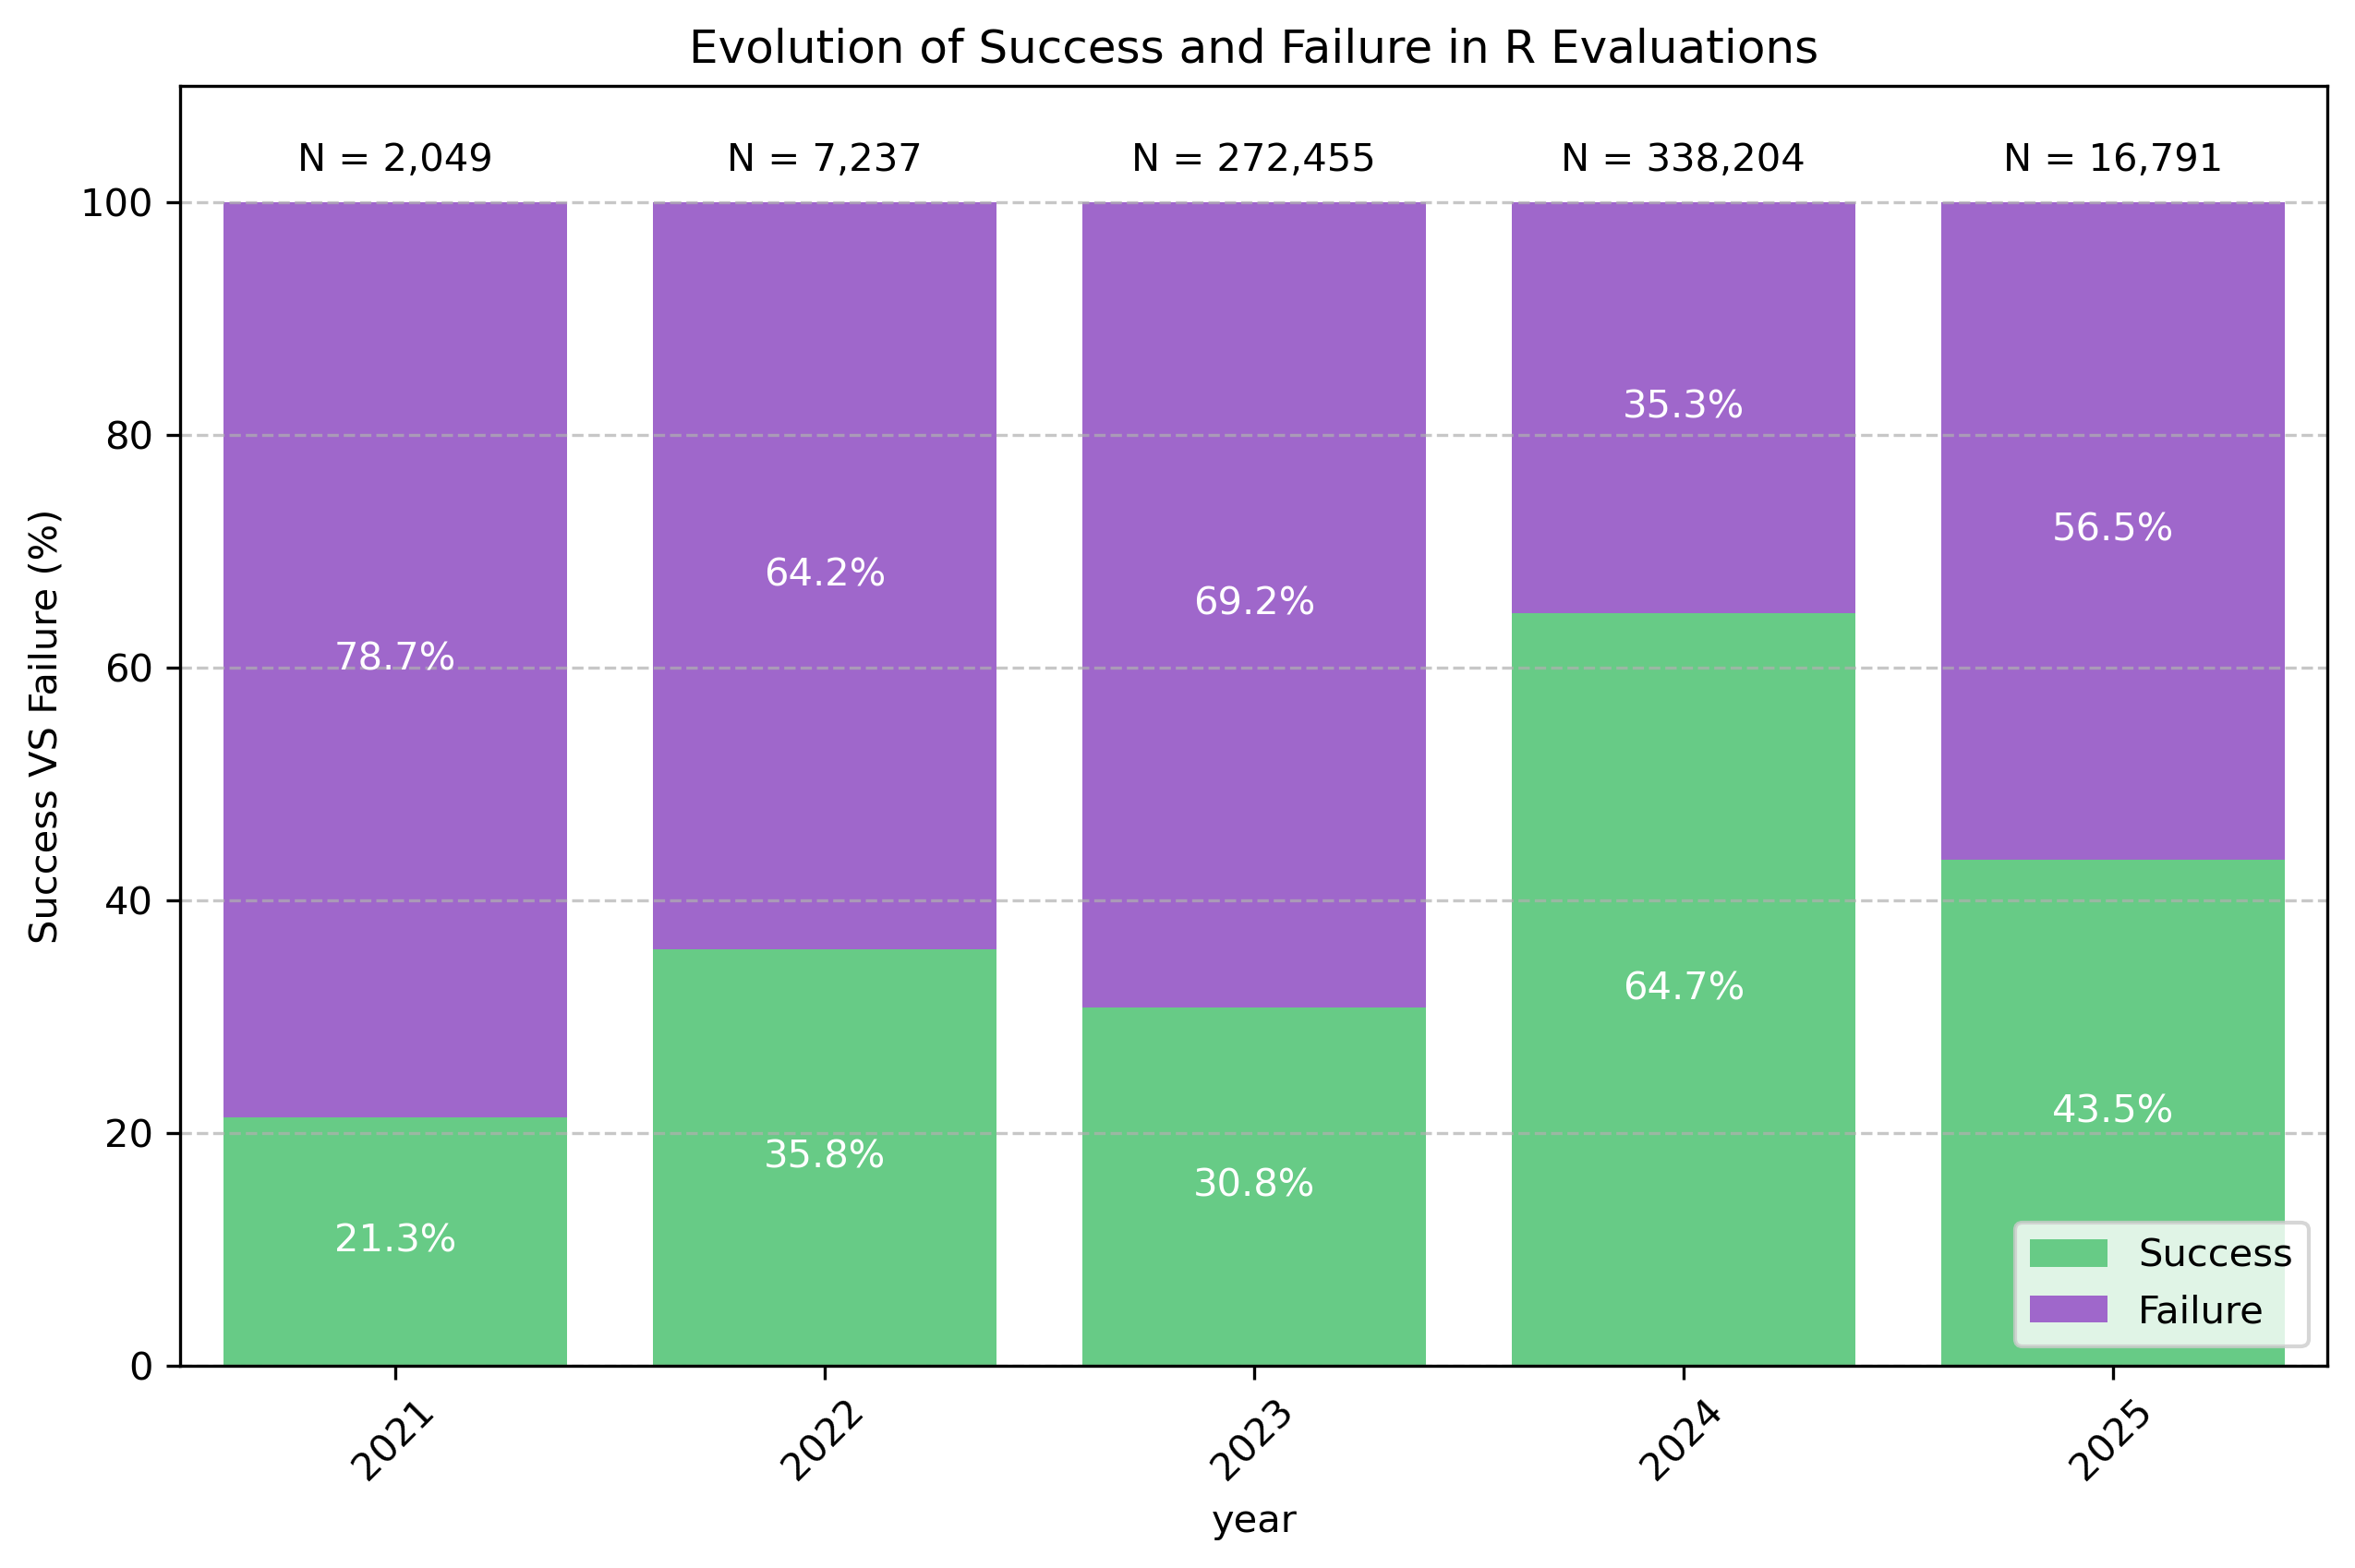

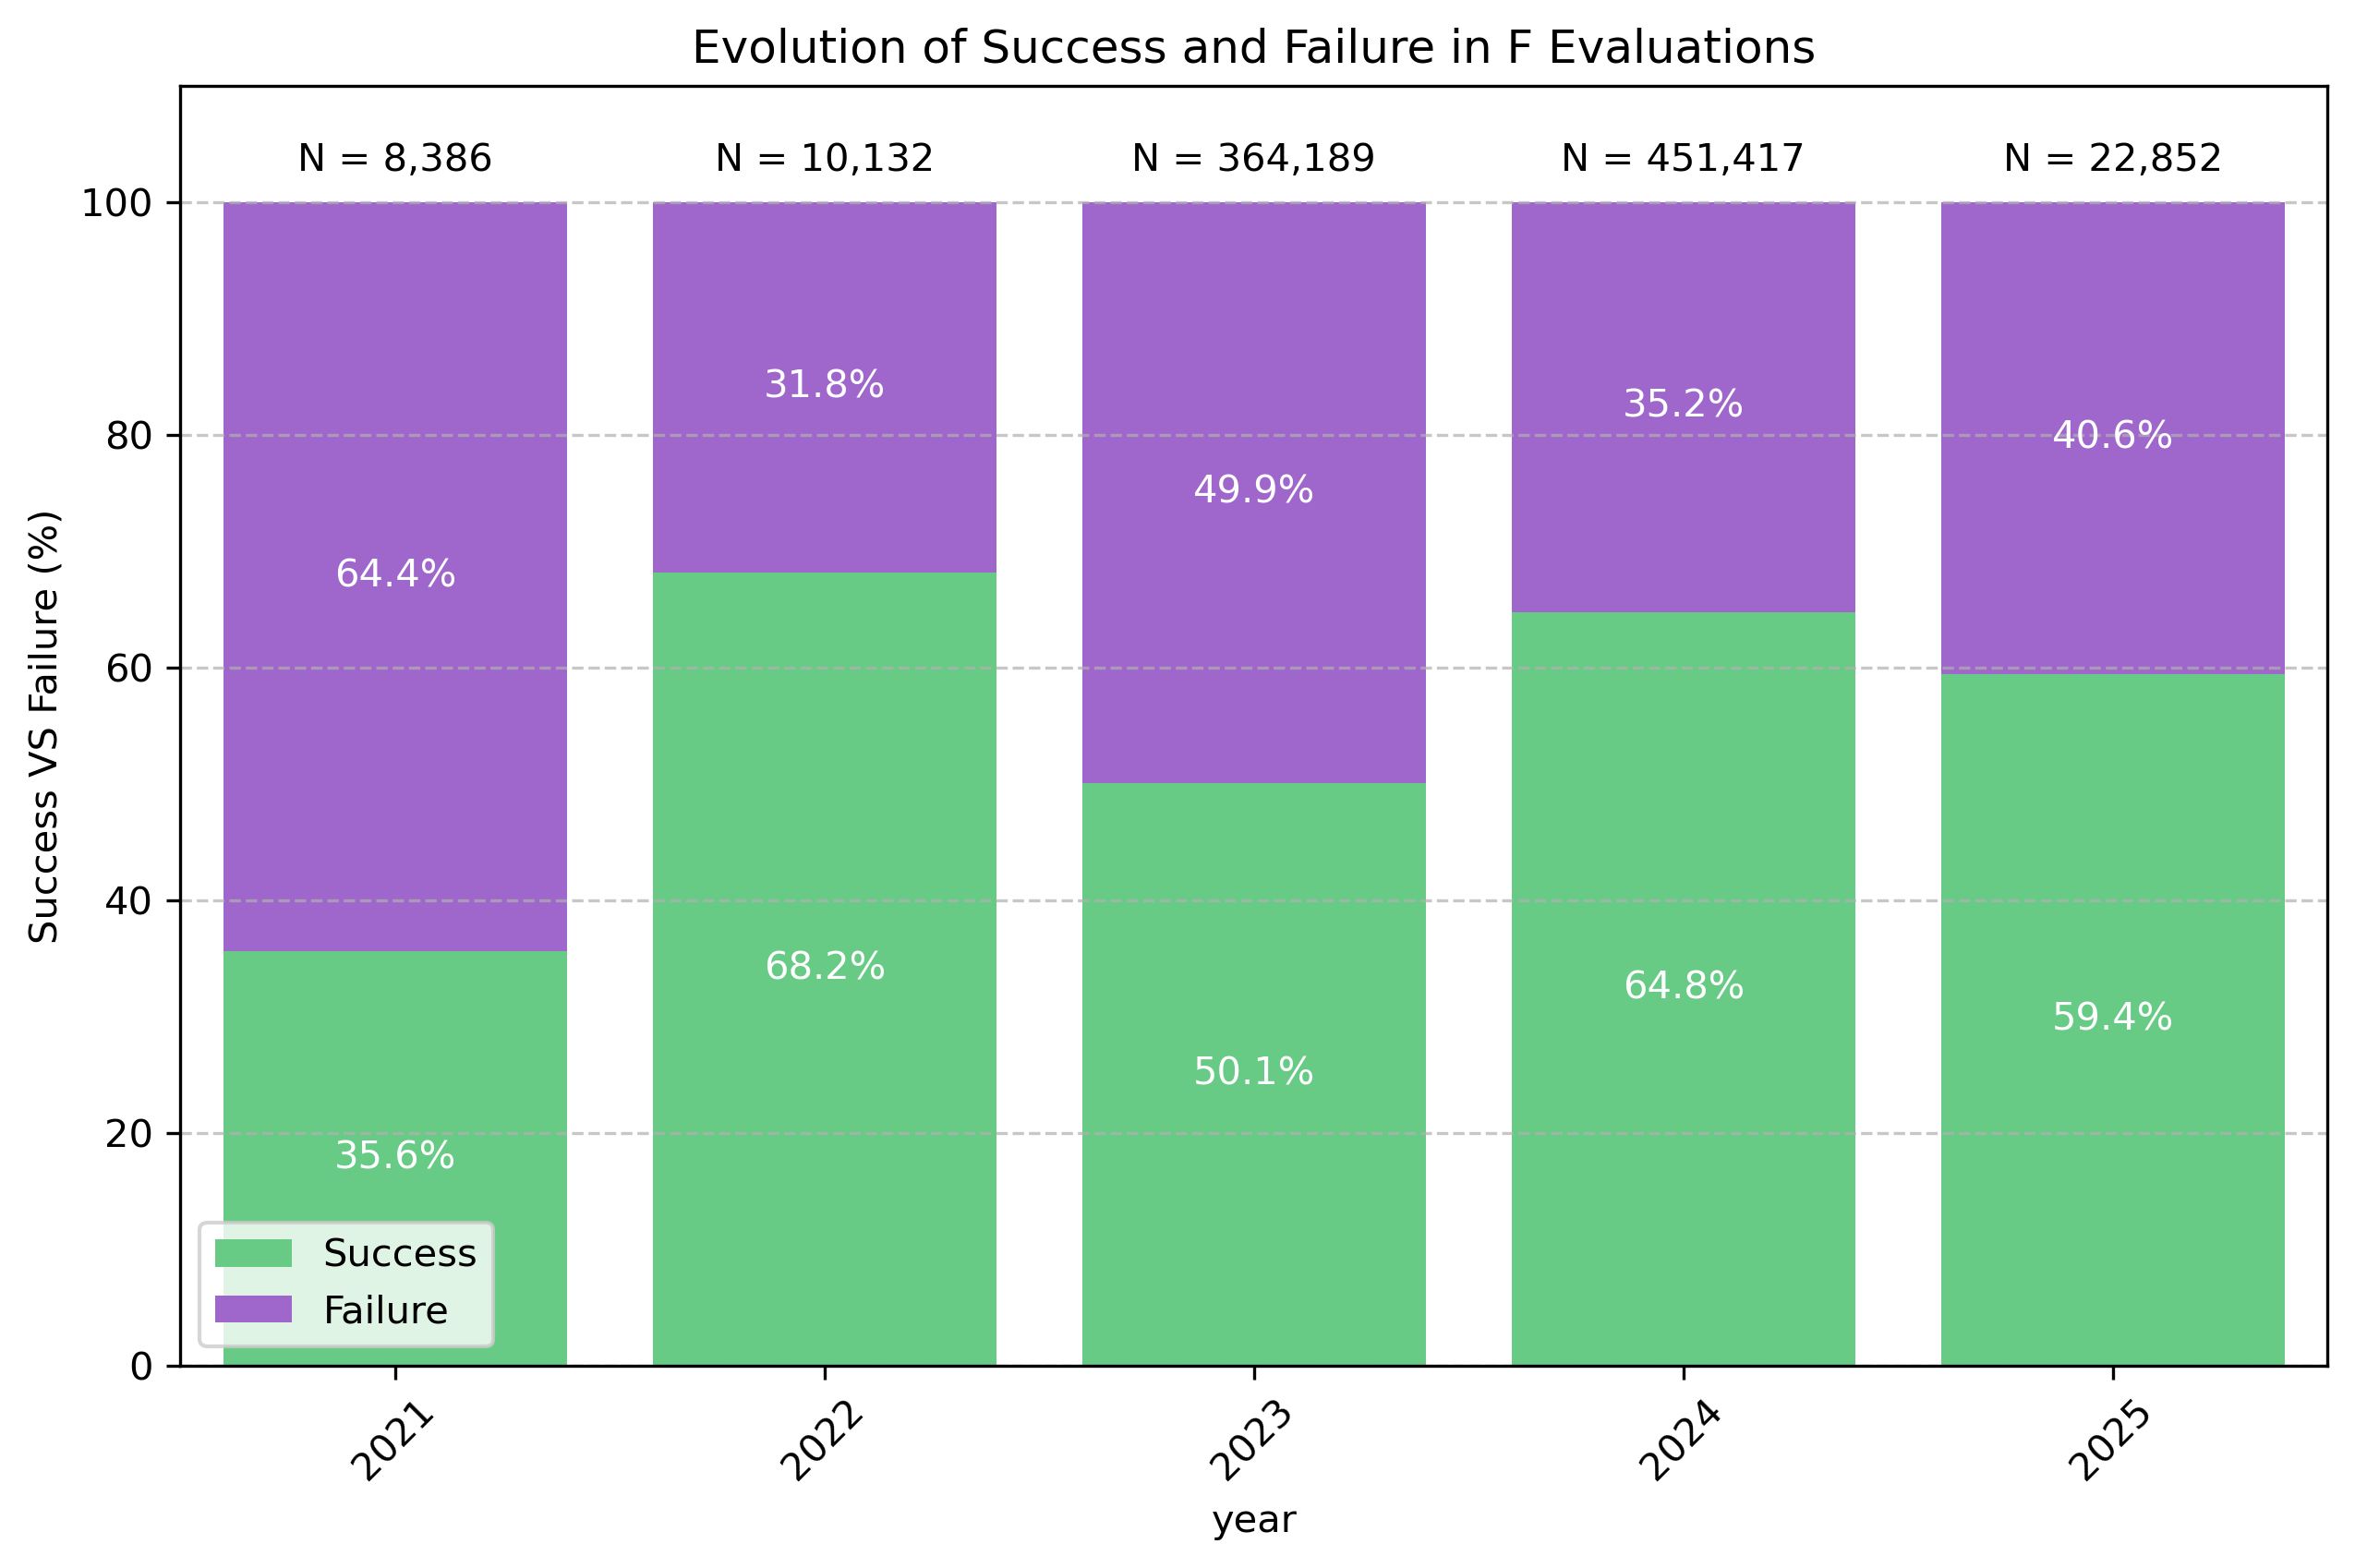

In [169]:
import glob

csvs = glob.glob("success_failure_evolution_*.csv")

for file in csvs:
    principle = file.split("_")[-1]
    principle = principle.split(".csv")[0] 

    output = pd.read_csv(file)

    plt.figure(figsize=(10, 6), dpi=300)
    sns.barplot(
        data=output,
        x="year",
        y="success_percent",
        label="Success",
        color=sns.color_palette("hls", 8)[3],
    )

    sns.barplot(
        data=output,
        x="year",
        y="failure_percent",
        label="Failure",
        color=sns.color_palette("hls", 8)[6],
        bottom=output["success_percent"],
    )
    # insert text inside each percent stacked bar in white
    for index, row in output.iterrows():
        plt.text(
            x=index,
            y=row["success_percent"] / 2,
            s=f"{row['success_percent']:.1f}%",
            color="white",
            ha="center",
            va="center",
        )
        plt.text(
            x=index,
            y=row["success_percent"] + row["failure_percent"] / 2,
            s=f"{row['failure_percent']:.1f}%",
            color="white",
            ha="center",
            va="center",
        )

    # insert the total number of evaluation for each year in black on the top
    for index, row in output.iterrows():
        total = row["success"] + row["failure"]
        plt.text(
            x=index,
            y=row["success_percent"] + row["failure_percent"] + 2,
            s=f"N = {int(total):,}",
            color="black",
            ha="center",
            va="bottom",
        )

    # set the y scale to cover also the 120 value
    plt.ylim(0, 110)

    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend()
    #plt.xlabel("Year")
    plt.ylabel("Success VS Failure (%)")
    plt.title(f"Evolution of Success and Failure in {principle} Evaluations")

    plt.savefig(
        f"success_failure_evolution_{principle}.pdf",
        dpi=300,
        format="pdf",
        bbox_inches="tight",
    )
    plt.show